## Imports

In [40]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

from xgboost import XGBClassifier

import joblib

## Load Dataset

In [41]:
X_train = pd.read_csv("../data/processed/X_train.csv")

X_test = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()

y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

print("Training shape :", X_train.shape)
print("Testing shape  :", X_test.shape)

Training shape : (453204, 33)
Testing shape  : (56746, 33)


## Train XGBoost

In [42]:
model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

model.fit(
    X_train,
    y_train
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


## Prediction

In [43]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:,1]

## Accuracy

In [44]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(f"Accuracy : {accuracy:.4f}")

Accuracy : 0.9992


## Precision

In [45]:
precision = precision_score(
    y_test,
    y_pred
)

print(f"Precision : {precision:.4f}")

Precision : 0.7551


## Recall

In [46]:
recall = recall_score(
    y_test,
    y_pred
)

print(f"Recall : {recall:.4f}")

Recall : 0.7789


## F1 Score

In [47]:
f1 = f1_score(
    y_test,
    y_pred
)

print(f"F1 Score : {f1:.4f}")

F1 Score : 0.7668


## Classification Report

In [48]:
print(classification_report(
    y_test,
    y_pred
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.76      0.78      0.77        95

    accuracy                           1.00     56746
   macro avg       0.88      0.89      0.88     56746
weighted avg       1.00      1.00      1.00     56746



## Confusion Matrix

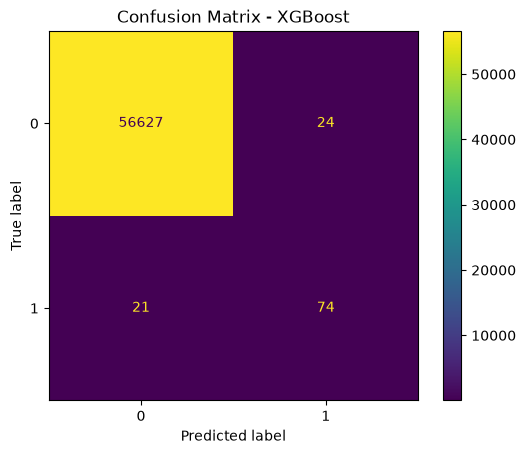

In [49]:
cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title("Confusion Matrix - XGBoost")

plt.show()

## ROC-AUC

In [50]:
roc_auc = roc_auc_score(
    y_test,
    y_prob
)

print(f"ROC-AUC : {roc_auc:.4f}")

ROC-AUC : 0.9597


## ROC Curve

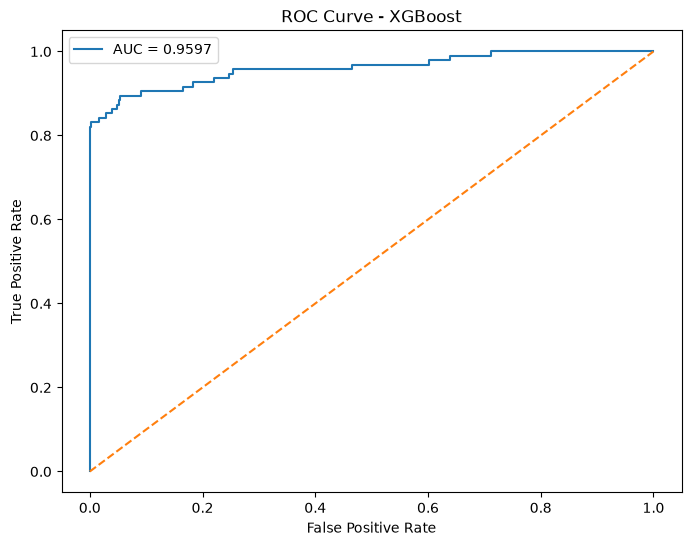

In [51]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - XGBoost")

plt.legend()

plt.show()

## Feature Importance

In [52]:
feature_importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance": model.feature_importances_

})

feature_importance = feature_importance.sort_values(

    by="Importance",

    ascending=False

)

feature_importance.head(20)

,Feature,Importance
14,V14,0.600775
4,V4,0.046634
8,V8,0.027268
32,Amount_Level,0.026984
10,V10,0.024867
17,V17,0.022138
12,V12,0.016974
13,V13,0.013960
9,V9,0.013331
11,V11,0.013213


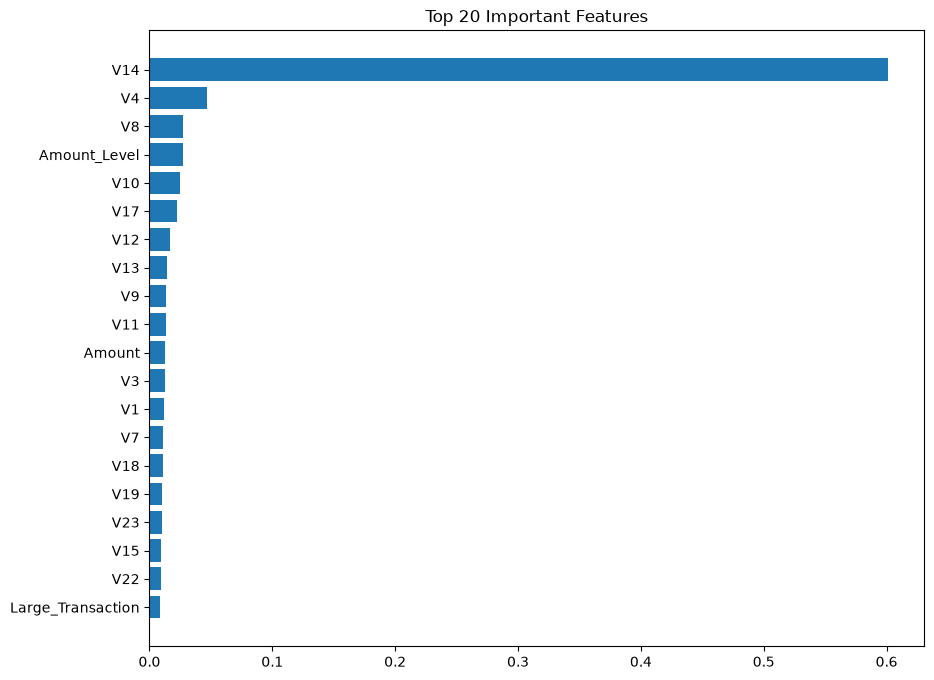

In [53]:
plt.figure(figsize=(10,8))

plt.barh(
    feature_importance["Feature"][:20],
    feature_importance["Importance"][:20]
)

plt.gca().invert_yaxis()

plt.title("Top 20 Important Features")

plt.show()

## Save Metrics

In [54]:
xgb_results = pd.DataFrame({

    "Model":["XGBoost"],

    "Accuracy":[accuracy],

    "Precision":[precision],

    "Recall":[recall],

    "F1 Score":[f1],

    "ROC-AUC":[roc_auc]

})

In [55]:
xgb_results.to_csv(
    "../results/xgboost_metrics.csv",
    index=False
)

## Save Model

In [56]:
joblib.dump(
    model,
    "../models/xgboost_model.pkl"
)

print("XGBoost model saved successfully.")

XGBoost model saved successfully.


## Saving Plot

In [57]:
plt.savefig("../artifacts/plots/xgboost_confusion_matrix.png",
            dpi=300,
            bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [58]:
plt.savefig("../artifacts/plots/xgboost_roc_curve.png",
            dpi=300,
            bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [59]:
plt.savefig("../artifacts/plots/xgboost_feature_importance.png",
            dpi=300,
            bbox_inches="tight")

<Figure size 640x480 with 0 Axes>